### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868429,2026-03-14 17:59:35,70588.203125,70588.203125,70588.203125,70588.203125,0.033,0.001,0.000,0.001,-1.000000,...,0.002,0.002,0.002,0.307,1.310,0.002,0.020,0.097,0.424,0.002
868430,2026-03-14 17:59:40,70588.203125,70588.203125,70588.203125,70588.203125,0.020,0.000,0.000,0.000,0.000000,...,0.002,0.002,0.002,0.307,1.310,0.002,0.020,0.097,0.424,0.002
868431,2026-03-14 17:59:45,70594.398438,70598.000000,70588.296875,70597.898438,1.209,1.120,1.115,0.005,0.991071,...,0.012,0.002,0.020,0.002,0.013,0.006,0.002,0.036,0.020,0.044
868432,2026-03-14 17:59:50,70595.796875,70595.796875,70595.796875,70595.796875,0.004,1.120,1.115,0.005,0.991071,...,0.026,0.012,0.002,0.020,0.002,0.013,0.006,0.002,0.036,0.020


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 868433/868433 [00:07<00:00, 111322.75it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.142425,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.135248,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.135248,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.131706,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.138937,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868429,1.856510,0.212352,3.099923,2.751858,0.000881,1.856508,0.669750,0.575177,0.151672,14.525059,...,0.102600,1.366612,1.707838,0.272638,0.258693,70588.203125,70588.203125,70588.203125,0.000000,0.000000
868430,1.856510,0.289883,2.996592,2.557591,0.000756,1.856508,0.648820,0.725796,0.250531,12.130958,...,0.102600,1.269179,1.698239,0.442125,0.518048,70588.203125,70588.203125,70588.203125,0.000070,0.000137
868431,1.973177,2.171219,3.223268,2.935186,0.000321,1.973174,0.003219,-7.239597,-2.680557,-68.151264,...,0.113971,0.712185,-8.986462,-0.976452,-0.989165,70588.296875,70598.000000,70597.898438,-0.000030,0.000000
868432,1.953255,1.262391,3.185878,2.957675,0.000201,1.953253,0.382500,0.145682,0.014784,13.925370,...,0.117148,0.766518,1.634324,0.068282,-0.002874,70595.796875,70595.796875,70595.796875,0.000000,0.000000


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00019
[50]	validation_0-rmse:0.00018
[100]	validation_0-rmse:0.00018
[150]	validation_0-rmse:0.00018
[200]	validation_0-rmse:0.00018
[250]	validation_0-rmse:0.00018
[300]	validation_0-rmse:0.00018
[350]	validation_0-rmse:0.00017
[400]	validation_0-rmse:0.00017
[450]	validation_0-rmse:0.00017
[500]	validation_0-rmse:0.00017
[550]	validation_0-rmse:0.00017
[600]	validation_0-rmse:0.00017
[650]	validation_0-rmse:0.00017
[700]	validation_0-rmse:0.00017
[750]	validation_0-rmse:0.00017
[800]	validation_0-rmse:0.00017
[850]	validation_0-rmse:0.00017
[900]	validation_0-rmse:0.00017
[950]	validation_0-rmse:0.00017
[1000]	validation_0-rmse:0.00017
[1050]	validation_0-rmse:0.00017
[1100]	validation_0-rmse:0.00017
[1150]	validation_0-rmse:0.00017
[1200]	validation_0-rmse:0.00017
[1250]	validation_0-rmse:0.00017
[1300]	validation_0-rmse:0.00017
[1350]	validation_0-rmse:0.00017
[1400]	validation_0-rmse:0.00017
[1450]	validation_0-rmse:0.00017
[1500]	validat

MAE                      : 0.000109
RMSE                     : 0.000172
R²                       : 0.194258
MAE / mean|Δ|            : 0.868307
RMSE / RMSE_base         : 0.897593
mean|Δ| (target)         : 0.000126

------------------------------------------------------------
Directional Accuracy     : 0.617373
Target Pos Ratio         : 0.480847
Profit Factor            : 2.666091
Avg Gain (correct)       : -0.000004
Avg Loss (incorrect)     : 0.000003

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6150, 0.6196)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000109, 0.00107]    0.000203         0.893367    -0.000007      17368
(6.22e-05, 0.000109]    0.000081         0.756967    -0.000005      17368
(4.37e-05, 6.22e-05]    0.000052         0.698065    -0.000003      17368


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


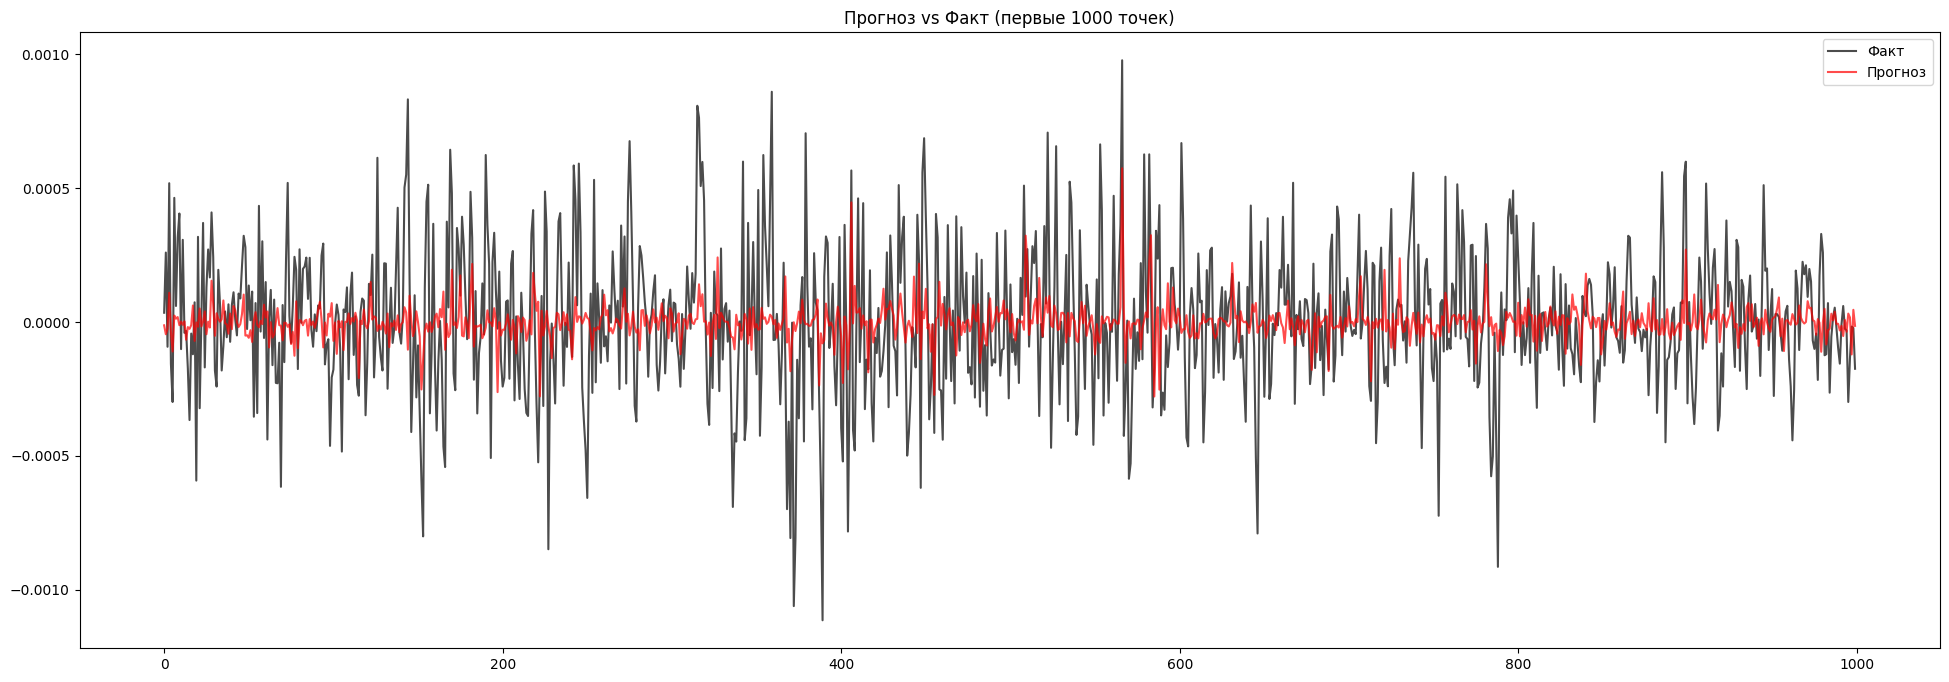

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00018
[100]	validation_0-rmse:0.00017
[150]	validation_0-rmse:0.00016
[200]	validation_0-rmse:0.00016
[250]	validation_0-rmse:0.00016
[300]	validation_0-rmse:0.00016
[350]	validation_0-rmse:0.00016
[400]	validation_0-rmse:0.00016
[450]	validation_0-rmse:0.00016
[500]	validation_0-rmse:0.00016
[550]	validation_0-rmse:0.00016
[600]	validation_0-rmse:0.00016
[650]	validation_0-rmse:0.00016
[700]	validation_0-rmse:0.00016
[750]	validation_0-rmse:0.00016
[800]	validation_0-rmse:0.00016
[850]	validation_0-rmse:0.00016
[900]	validation_0-rmse:0.00016
[950]	validation_0-rmse:0.00016
[1000]	validation_0-rmse:0.00016
[1050]	validation_0-rmse:0.00016
[1100]	validation_0-rmse:0.00016
[1150]	validation_0-rmse:0.00016
[1200]	validation_0-rmse:0.00016
[1250]	validation_0-rmse:0.00016
[1300]	validation_0-rmse:0.00016
[1350]	validation_0-rmse:0.00016
[1400]	validation_0-rmse:0.00016
[1421]	validation_0-rmse:0.00016
Модель сохране

MAE                      : 0.000106
RMSE                     : 0.000159
R²                       : 0.388882
MAE / mean|Δ|            : 0.565328
RMSE / RMSE_base         : 0.573445
mean|Δ| (target)         : 0.000188

------------------------------------------------------------
Directional Accuracy     : 0.910900
Target Pos Ratio         : 0.910900
Profit Factor            : 32704417931.828136
Avg Gain (correct)       : 0.000207
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9096, 0.9122)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
           quantile  confidence  directional_acc  mean_return  n_samples
 (0.00036, 0.00253]    0.000485         0.999885     0.000477      17368
(0.000271, 0.00036]    0.000309         0.998561     0.000307      17368
(0.00022, 0.000271]    0.000242         0.991767     0.000241      17

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


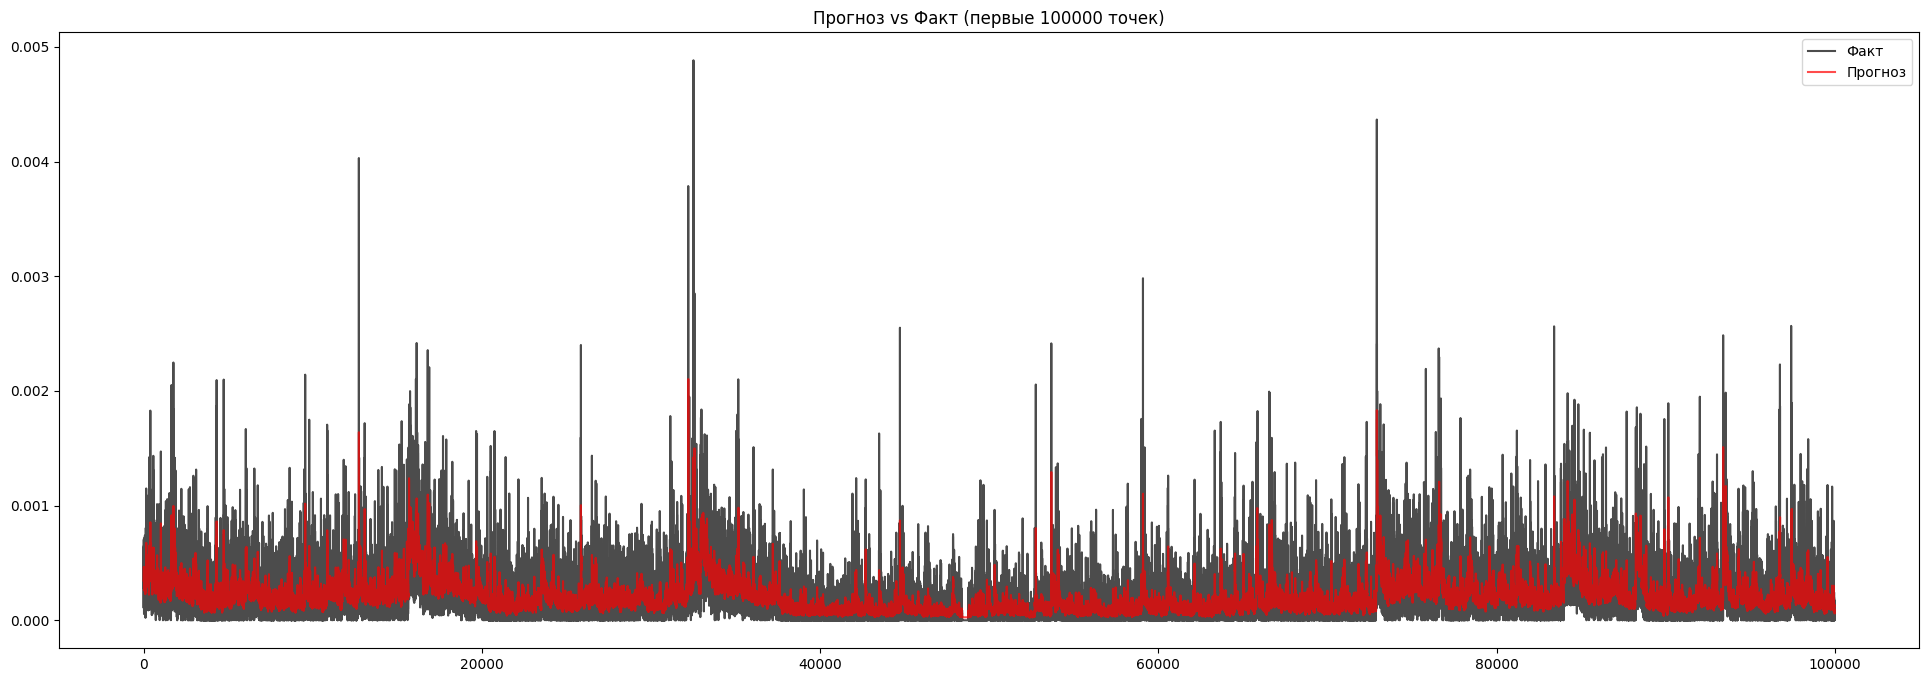

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)